<!-- codex-architecture-notes -->
## Architectural Notes

**Purpose:** Creates and diagnoses train/validation/test splits for the primary model dataset.

**Notebook Shape:** 40 cells (13 code, 27 markdown).

**Inputs / Data Sources:**
- `df_primary = pd.read_parquet(PARQUET_PATH)`
- `df_train_rt = pd.read_parquet(TRAIN_PATH)`
- `df_valid_rt = pd.read_parquet(VALID_PATH)`
- `df_test_rt  = pd.read_parquet(TEST_PATH)`

**Outputs / Side Effects:**
- `df_train.to_parquet(TRAIN_PATH, index=True)`
- `df_valid.to_parquet(VALID_PATH, index=True)`
- `df_test.to_parquet(TEST_PATH,   index=True)`

**Logic Flow:**
1. Load primary engineered data.
2. Inspect candidate split keys and distributions.
3. Create train/valid/test partitions.
4. Write parquet splits and compare distributions.

**Maintainability Notes:** Split logic affects evaluation validity; promote the final split rules to a versioned script to keep experiments reproducible.


# Temporal Split Diagnostics

**Purpose:** Read-only analysis of `df_primary` — temporal split definition, count verification, and exam-course balance checks.  
**Nothing is modified, dropped, or exported.** Each code cell does one thing; the markdown cell below it explains what the output means.

**Configuration** — this notebook is the sole owner of the **base** split generation (`df_{train,valid,test}_base.parquet` under `MODEL_DATA_DIR`). Downstream stages (`02_course_difficulty.ipynb`, `03_diploma_type_bucketing.ipynb`) read a generation and write their own distinct files — they never overwrite these.

In [1]:
from src.paths import MODEL_DATA_DIR, FINAL_DIR, assert_data_root
from src.io_utils import save_parquet


**Step 1** — Load the parquet file and inspect shape + dtypes for the four key columns.

In [2]:
import pandas as pd

PARQUET_PATH = FINAL_DIR / "without_outliers.parquet"

# Data-root guard (governance contract 12): refuse to run against a freshly
# created empty tree or a missing/empty input artifact.
assert_data_root(PARQUET_PATH)

df_primary = pd.read_parquet(PARQUET_PATH)

print("Full DataFrame shape:", df_primary.shape)
print("\nDtypes for key columns:")
print(df_primary[["part_id", "part_year", "part_semester", "is_high_credit_course"]].dtypes)

Full DataFrame shape: (749523, 65)

Dtypes for key columns:
part_id                  string
part_year                 Int64
part_semester             Int64
is_high_credit_course     int64
dtype: object


**What this shows:** Total row count and column dtypes.  
Confirm that `part_year` and `part_semester` are `Int64` (nullable) — this matters for the float-cast in Step 3.  
If either appears as `object`, the cast still works but note it here.

**Step 2** — Row counts grouped by `part_year`, sorted ascending, including NaN/missing years.

In [3]:
year_counts = (
    df_primary["part_year"]
    .value_counts(dropna=False)   # include NaN bucket
    .sort_index()                  # ascending year order
)

print("Row counts by part_year (NaN shown if present):")
print(year_counts.to_string())
print(f"\nSum of all buckets: {year_counts.sum():,}  |  df_primary total: {len(df_primary):,}")

Row counts by part_year (NaN shown if present):
part_year
2005      114
2006       74
2007      149
2008      978
2009     2335
2010     2355
2011    13684
2012    10906
2013    19554
2014    28733
2015    36229
2016    44929
2017    47928
2018    48971
2019    56063
2020    64198
2021    73265
2022    76941
2023    79157
2024    75383
2025    67577

Sum of all buckets: 749,523  |  df_primary total: 749,523


**What this shows:** Full year distribution before any splitting.  
Look for: years outside 2013–2024, the anomalous 2016 entry, NaN rows, and any unexpected spikes or gaps that might affect split balance.

**Step 3** — Define the three temporal split masks. Both `part_year` and `part_semester` are cast to float64 (nullable Int64 with `<NA>` breaks boolean indexing).

- **train**: 2005–2021
- **val**: 2022–2023
- **test**: all of 2024 + semester 1 of 2025 only — 2025-semester-2 is excluded (incomplete semester)

After defining the masks, compute `unassigned_mask`, then explicitly confirm that 2025-semester-2 rows land in `unassigned` and NOT in `test`.

In [4]:
year_f = df_primary['part_year'].astype('float64')
sem_f  = df_primary['part_semester'].astype('float64')
part_num = year_f * 10 + sem_f          # 2023 sem 3 -> 20233, matches your log's notation

train_mask = (part_num >= 20051) & (part_num <= 20233)
val_mask   = (part_num >= 20241) & (part_num <= 20243)
test_mask  = (part_num == 20251)        # 20252 AND 20253 excluded — pending completeness check

unassigned_mask = ~train_mask & ~val_mask & ~test_mask
n_unassigned = int(unassigned_mask.sum())
print(f'Unassigned rows (in no split): {n_unassigned:,}')

for yr, sm in [(2025, 2), (2025, 3)]:
    m = (year_f == yr) & (sem_f == sm)
    print(f'{yr} sem {sm}: total={int(m.sum()):,}  '
          f'unassigned={int((m & unassigned_mask).sum()):,}  '
          f'in_test={int((m & test_mask).sum()):,}')

if n_unassigned > 0:
    print(df_primary.loc[unassigned_mask, ['part_year', 'part_semester']]
          .value_counts(dropna=False).sort_index().to_string())

Unassigned rows (in no split): 32,948
2025 sem 2: total=32,943  unassigned=32,943  in_test=0
2025 sem 3: total=5  unassigned=5  in_test=0
part_year  part_semester
2025       2                32943
           3                    5


**What this shows:** Whether every row can be assigned to exactly one split, and explicit confirmation that 2025-semester-2 is excluded from test. `n_2025_s2_in_test` must be 0 — if it isn't, the test mask is wrong. `n_2025_s2_unassigned` must equal `n_2025_s2_total` (all incomplete-semester rows are in the unassigned bucket). Any other unassigned rows (NaN years, years < 2005, unexpected semesters) also appear in the breakdown.

**Step 4** — Assert that train + val + test + unassigned equals the total row count exactly. Fail loudly if not.

In [5]:
n_train      = int(train_mask.sum())
n_val        = int(val_mask.sum())
n_test       = int(test_mask.sum())
n_unassigned = int(unassigned_mask.sum())
n_total      = len(df_primary)

computed_total = n_train + n_val + n_test + n_unassigned

assert computed_total == n_total, (
    f"Partition mismatch!\n"
    f"  train={n_train:,}  val={n_val:,}  test={n_test:,}  unassigned={n_unassigned:,}\n"
    f"  sum={computed_total:,}  actual total={n_total:,}\n"
    f"  difference={n_total - computed_total:,}"
)

print("Partition check PASSED — all rows accounted for.")
print(f"  train={n_train:,}  val={n_val:,}  test={n_test:,}  unassigned={n_unassigned:,}  total={n_total:,}")

Partition check PASSED — all rows accounted for.
  train=606,563  val=75,383  test=34,629  unassigned=32,948  total=749,523


**What this shows:** A hard guarantee that the four masks are mutually exclusive and collectively exhaustive.  
If the assert fires, the error message prints all four counts so you can diagnose the overlap or gap immediately.

**Step 5** — Create `df_train`, `df_valid`, `df_test` as filtered views (original index preserved, nothing reset).

In [6]:
# Use .loc — preserves the original index for later alignment with other dataframes
df_train = df_primary.loc[train_mask]
df_valid = df_primary.loc[val_mask]
df_test  = df_primary.loc[test_mask]

print(f"df_train shape : {df_train.shape}")
print(f"df_valid shape : {df_valid.shape}")
print(f"df_test  shape : {df_test.shape}")

df_train shape : (606563, 65)
df_valid shape : (75383, 65)
df_test  shape : (34629, 65)


**What this shows:** Confirmation that the three split DataFrames were created and have the expected row counts (matching n_train / n_val / n_test from Step 4).  
The original integer index is kept intact — no `reset_index` — so these can be aligned to other dataframes later.

**Step 6** — Summary table: split name, row count, % of total, min and max `part_year`.

In [7]:
total_rows = len(df_primary)

summary_rows = []
for name, df in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    n = len(df)
    summary_rows.append({
        "split":        name,
        "row_count":    n,
        "pct_of_total": f"{n / total_rows * 100:.2f}%",
        "min_year":     df["part_year"].min(),
        "max_year":     df["part_year"].max(),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

split  row_count pct_of_total  min_year  max_year
train     606563       80.93%      2005      2023
valid      75383       10.06%      2024      2024
 test      34629        4.62%      2025      2025


**What this shows:** A one-glance overview of split sizes and year ranges.  
The `pct_of_total` column lets you immediately see if train is large enough relative to val/test, and `min_year` / `max_year` confirm no year leaked across boundaries.

**Step 7** — Count rows where `part_year == 2016` AND `part_semester == 4` (known anomalous semester) within each split, and check how many of those have `is_high_credit_course == 1`.

In [8]:
def anomalous_semester_counts(df, label):
    """Return rows where part_year==2016 and part_semester==4, within a given split."""
    yf = df["part_year"].astype("float64")
    sf = df["part_semester"].astype("float64")
    mask = (yf == 2016) & (sf == 4)
    subset = df.loc[mask]
    hcc_count = int((subset["is_high_credit_course"] == 1).sum())
    print(f"  {label:<8}: {len(subset):>8,} rows with 2016/sem4  "
          f"  (of those, is_high_credit_course==1: {hcc_count:,})")

print("Rows with part_year=2016 AND part_semester=4 (anomalous semester):")
anomalous_semester_counts(df_train, "train")
anomalous_semester_counts(df_valid, "valid")
anomalous_semester_counts(df_test,  "test")

Rows with part_year=2016 AND part_semester=4 (anomalous semester):
  train   :    5,166 rows with 2016/sem4    (of those, is_high_credit_course==1: 38)
  valid   :        0 rows with 2016/sem4    (of those, is_high_credit_course==1: 0)
  test    :        0 rows with 2016/sem4    (of those, is_high_credit_course==1: 0)


**What this shows:** How the known anomalous 2016/semester-4 entry distributes across splits.  
Because 2016 is inside the training window (2013–2021), all of these rows should land exclusively in `df_train` — valid and test counts should be zero.  
The `is_high_credit_course` sub-count flags whether the anomaly coincides with the exam course, which could bias training.

**Step 8** — Count `is_high_credit_course == 1` rows in each split, as both absolute counts and percentages of that split's total.

In [9]:
print(f"{'Split':<8} {'HCC=1 count':>13} {'Split total':>13} {'% of split':>12}")
print("-" * 50)

for name, df in [("train", df_train), ("valid", df_valid), ("test", df_test)]:
    hcc   = int((df["is_high_credit_course"] == 1).sum())
    total = len(df)
    pct   = hcc / total * 100 if total > 0 else 0.0
    print(f"{name:<8} {hcc:>13,} {total:>13,} {pct:>11.4f}%")

# Overall baseline for comparison
hcc_all     = int((df_primary["is_high_credit_course"] == 1).sum())
overall_pct = hcc_all / len(df_primary) * 100
print("-" * 50)
print(f"{'overall':<8} {hcc_all:>13,} {len(df_primary):>13,} {overall_pct:>11.4f}%  <- baseline")

Split      HCC=1 count   Split total   % of split
--------------------------------------------------
train              515       606,563      0.0849%
valid              116        75,383      0.1539%
test               141        34,629      0.4072%
--------------------------------------------------
overall            812       749,523      0.1083%  <- baseline


**What this shows:** Whether the 24-credit exam course (`is_high_credit_course == 1`) is proportionally represented across splits.  
The overall baseline (last row) is the reference point — if train's percentage is close to it, the split is roughly balanced for this class.  
A large gap (e.g., exam course is 3% overall but only 0.5% in val) would indicate temporal skew that could hurt model evaluation.

**Step 9a** — Bar chart of total row count per `part_year` (full dataset), with shaded bands marking the train/val/test boundaries.

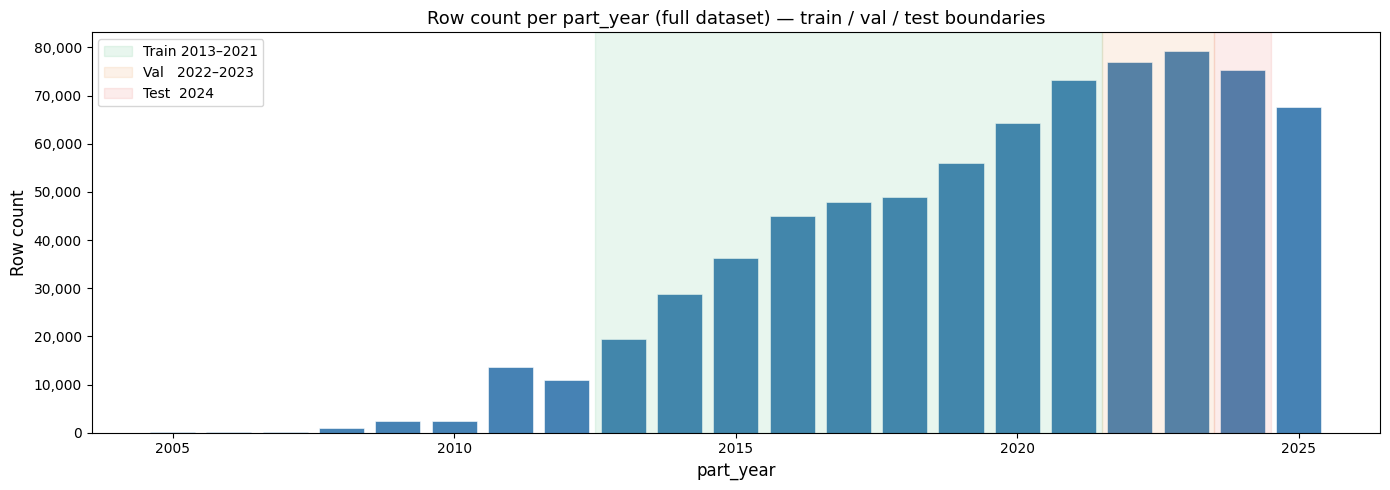

In [10]:
import matplotlib.pyplot as plt

year_dist = (
    df_primary["part_year"]
    .astype("float64")
    .value_counts()
    .sort_index()
    .dropna()              # drop NaN index for plotting (NaN year rows are counted in Step 3)
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(year_dist.index, year_dist.values, color="steelblue", edgecolor="white", linewidth=0.4)

# Shaded bands for each split (half-year padding around boundaries for visual clarity)
ax.axvspan(2012.5, 2021.5, alpha=0.10, color="#27ae60", label="Train 2013–2021")
ax.axvspan(2021.5, 2023.5, alpha=0.10, color="#e67e22", label="Val   2022–2023")
ax.axvspan(2023.5, 2024.5, alpha=0.10, color="#e74c3c", label="Test  2024")

ax.set_xlabel("part_year", fontsize=12)
ax.set_ylabel("Row count", fontsize=12)
ax.set_title("Row count per part_year (full dataset) — train / val / test boundaries", fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

**What this shows:** The volume distribution across years and how much data each split inherits.  
Look for years with unusually low bars (data gaps), sudden spikes, and whether the test year (2024) has enough rows to be a meaningful evaluation set.

**Step 9b** — Grouped bar chart comparing `is_high_credit_course == 1` as a **percentage of each split's total rows** (not raw count) across train / val / test.

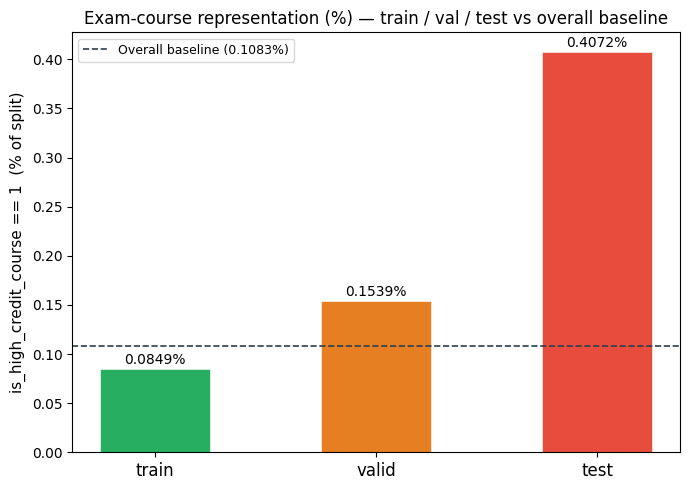

In [11]:
import numpy as np

split_labels = ["train", "valid", "test"]
split_dfs    = [df_train, df_valid, df_test]
bar_colors   = ["#27ae60", "#e67e22", "#e74c3c"]

hcc_pcts = [
    (df["is_high_credit_course"] == 1).sum() / len(df) * 100
    for df in split_dfs
]

# Overall baseline percentage
overall_pct = (df_primary["is_high_credit_course"] == 1).sum() / len(df_primary) * 100

fig, ax = plt.subplots(figsize=(7, 5))
x    = np.arange(len(split_labels))
bars = ax.bar(x, hcc_pcts, color=bar_colors, edgecolor="white", linewidth=0.4, width=0.5)

# Annotate bars with exact percentage
for bar, pct in zip(bars, hcc_pcts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + overall_pct * 0.02,
        f"{pct:.4f}%",
        ha="center", va="bottom", fontsize=10
    )

# Horizontal dashed line = overall baseline
ax.axhline(overall_pct, color="#2c3e50", linestyle="--", linewidth=1.2,
           label=f"Overall baseline ({overall_pct:.4f}%)")

ax.set_xticks(x)
ax.set_xticklabels(split_labels, fontsize=12)
ax.set_ylabel("is_high_credit_course == 1  (% of split)", fontsize=11)
ax.set_title("Exam-course representation (%) — train / val / test vs overall baseline", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**What this shows:** Whether the exam course is proportionally balanced across splits.  
The dashed baseline is the overall dataset rate. Bars close to the baseline mean the temporal split didn't concentrate or dilute the exam course in any one window — which is what we want.  
A bar far below the baseline (especially for val or test) would mean those splits have very few exam-course examples, which would make evaluation noisy.

## Final Summary

> **Fill this in after running the notebook.** Below are the questions to answer:

1. **Split sizes:** How many rows are in train / val / test, and what percentage of the total does each represent?

2. **Unassigned rows:** Were any rows left unassigned (Step 3)? If yes, what `part_year` values caused it, and how many?

3. **Anomalous semester 2016/4:** Did semester `20164` rows appear? All should be in train (year 2016 is within 2013–2021). Did any bleed into val or test? Did they coincide with `is_high_credit_course == 1`?

4. **Exam-course balance:** Is `is_high_credit_course == 1` proportionally represented in train relative to the overall baseline? Is val or test significantly under-represented?

5. **Next steps:** Based on the above, list any concerns that need to be addressed before building the model (e.g., remove semester 2016/4, handle unassigned rows, oversample exam course in training data, etc.).

**Step 10 (Save)** — Persist the three split DataFrames to parquet under `MODEL_DATA_DIR` as the **base generation** (`df_*_base.parquet`) for use by downstream notebooks.

In [12]:
# D2 (distinct split generations): this notebook owns the BASE generation only.
# Enrichment stages read these and write their own df_*_difficulty / df_*_final
# files — nothing overwrites another stage's artifact.
TRAIN_PATH = MODEL_DATA_DIR / "df_train_base.parquet"
VALID_PATH = MODEL_DATA_DIR / "df_valid_base.parquet"
TEST_PATH = MODEL_DATA_DIR / "df_test_base.parquet"

MODEL_DATA_DIR.mkdir(parents=True, exist_ok=True)

save_parquet(df_train, TRAIN_PATH, index=True)
save_parquet(df_valid, VALID_PATH, index=True)
save_parquet(df_test, TEST_PATH, index=True)

for label, path, df in [('train', TRAIN_PATH, df_train),
                        ('valid', VALID_PATH, df_valid),
                        ('test',  TEST_PATH,  df_test)]:
    size_mb = path.stat().st_size / 1_048_576
    print(f'  {label:<6}: {df.shape}  ->  {path}  ({size_mb:.1f} MB)')

print('\nBase splits saved (distinct base generation — no difficulty columns).')
print('02_course_difficulty.ipynb reads these and writes its own df_*_difficulty.parquet files.')

  train : (606563, 65)  ->  D:\AI\Real projects\Academic_Advisor\data\model_data\df_train_base.parquet  (22.1 MB)
  valid : (75383, 65)  ->  D:\AI\Real projects\Academic_Advisor\data\model_data\df_valid_base.parquet  (2.9 MB)
  test  : (34629, 65)  ->  D:\AI\Real projects\Academic_Advisor\data\model_data\df_test_base.parquet  (1.2 MB)

Base splits saved (distinct base generation — no difficulty columns).
02_course_difficulty.ipynb reads these and writes its own df_*_difficulty.parquet files.


**What this shows:** File path, shape, and on-disk size confirm all three splits saved. The original index is preserved (`index=True`). These are the **base** generation files (no difficulty columns). Under D2, `02_course_difficulty.ipynb` reads them and writes its own distinct `df_*_difficulty.parquet` files — the base files are never overwritten. The round-trip check in the next cell verifies the save/load cycle is lossless.

**Step 11 (Round-trip check)** — Reload all three saved files from disk and assert their shapes exactly match the in-memory DataFrames, proving the save/load cycle is lossless before `02_course_difficulty.ipynb` depends on them.

In [13]:
import pandas as pd

# Reload from disk to verify the saved files are identical to what's in memory
df_train_rt = pd.read_parquet(TRAIN_PATH)
df_valid_rt = pd.read_parquet(VALID_PATH)
df_test_rt  = pd.read_parquet(TEST_PATH)

assert df_train_rt.shape == df_train.shape, (
    f'Round-trip mismatch — train: in-memory={df_train.shape}, reloaded={df_train_rt.shape}'
)
assert df_valid_rt.shape == df_valid.shape, (
    f'Round-trip mismatch — valid: in-memory={df_valid.shape}, reloaded={df_valid_rt.shape}'
)
assert df_test_rt.shape == df_test.shape, (
    f'Round-trip mismatch — test: in-memory={df_test.shape}, reloaded={df_test_rt.shape}'
)

print('Round-trip check PASSED — saved files match in-memory splits exactly.')
print(f'  train : {df_train_rt.shape}')
print(f'  valid : {df_valid_rt.shape}')
print(f'  test  : {df_test_rt.shape}')

Round-trip check PASSED — saved files match in-memory splits exactly.
  train : (606563, 65)
  valid : (75383, 65)
  test  : (34629, 65)


**What this shows:** Shapes match confirms that saving with `index=True` and reloading via `pd.read_parquet` doesn't silently drop rows, columns, or the index. If an assertion fires, the mismatch message shows both shapes for comparison — investigate before running `02_course_difficulty.ipynb`.